In [184]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import spacy
from spacy.lang.de import German
import os
from tqdm import tqdm

In [185]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'KPD', 'BP', 'DP', 'WAV', 'Z', 'fraktionslos' ] 

In [186]:
datapath = r'data/parsed_protocols/20_092_2023-03-17.json'
with open(datapath) as f:
    protocol = json.load(f)

In [187]:
party_indices = {party: i for i, party in enumerate(parties)}

comment_matrix = np.zeros([len(parties), len(parties)])

for speech in protocol:
    party_speaker = speech['speaker']['party']
    speaker_party_index = party_indices[party_speaker]
    for comment in speech['comments']:
        comment_party = comment['commentator']['party']
        comment_matrix[speaker_party_index][party_indices[comment_party]] += 1

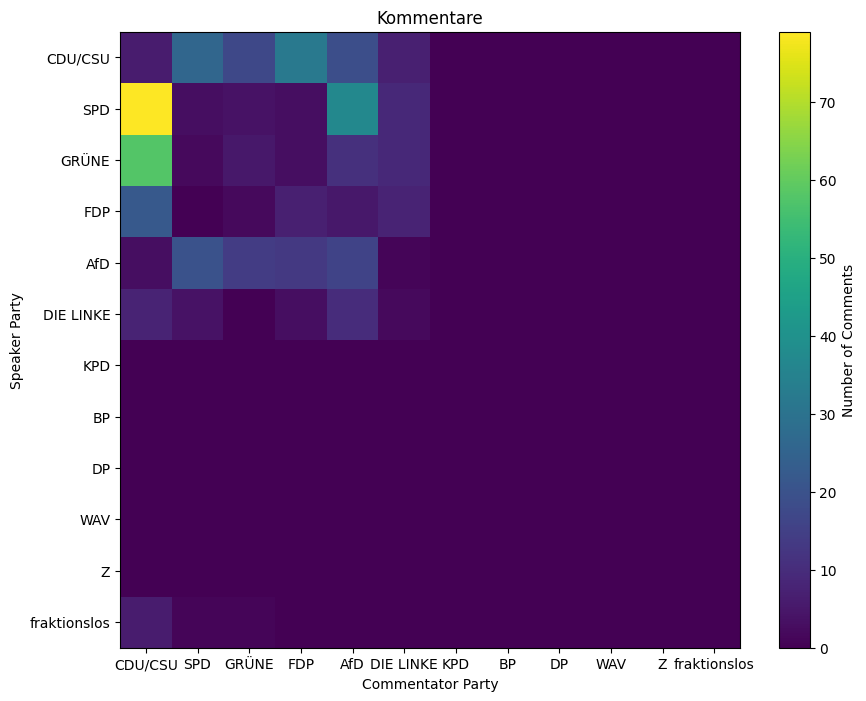

In [188]:
plt.figure(figsize=(10, 8))
plt.imshow(comment_matrix, cmap='viridis', aspect='auto')

# labels
plt.xticks(ticks=np.arange(len(parties)), labels=parties)
plt.yticks(ticks=np.arange(len(parties)), labels=parties)
plt.colorbar(label='Number of Comments')
plt.xlabel('Commentator Party')
plt.ylabel('Speaker Party')
plt.title('Kommentare')

plt.show()

Let's look at how many sentences a representative is allowed to speak before being interrupted

In [189]:
#nlp = spacy.load("de_core_news_sm")
nlp = German()
nlp.add_pipe('sentencizer')

In [190]:
# first concat all the speeches from each party into one
num_sents = np.zeros(len(parties))
for speech in protocol:
    party_speaker = speech['speaker']['party']
    doc = nlp(speech['text'])
    #num_sents[party_indices[party_speaker]] +=  sum(1 for token in doc if token.is_alpha) #sum(1 for token in doc if token.is_alpha)
    num_sents[party_indices[party_speaker]] +=  sum(1 for token in doc if token.is_alpha)

In [191]:
print(list(num_sents))

[15204.0, 17853.0, 8843.0, 8928.0, 6471.0, 4540.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1356.0]


In [192]:
comment_matrix_normalized_sents = comment_matrix.copy()
for i in range(len(parties)):
    comment_matrix_normalized_sents[i,:] /= num_sents[i]+1 #smoothing for 0 values

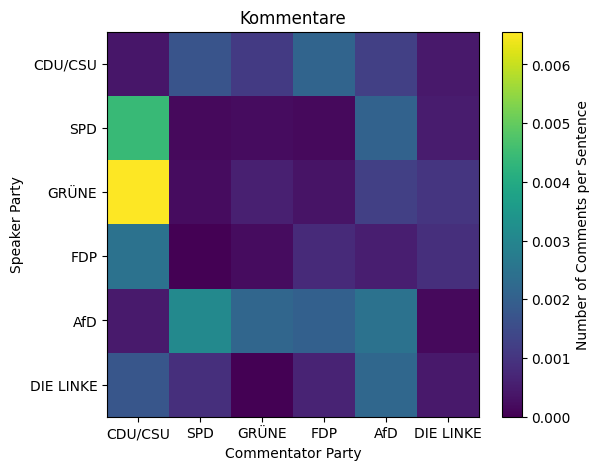

In [193]:
# now normalized + focus only on relevant parties
plt.figure(figsize=(6, 5))
plt.imshow(comment_matrix_normalized_sents[:6,:6], cmap='viridis', aspect='auto')

# labels
plt.xticks(ticks=np.arange(6), labels=parties[:6])
plt.yticks(ticks=np.arange(6), labels=parties[:6])
plt.colorbar(label='Number of Comments per Sentence')
plt.xlabel('Commentator Party')
plt.ylabel('Speaker Party')
plt.title('Kommentare')

plt.show()

This is still not showing the whole picture. After all, there are more than double of people in the CDU/CSU-Fraktion than in the AfD Fraktion  
So let's normalize by number of seats. The percentages of second votes can be found [here](https://www.bundestag.de/parlament/wahlen/ergebnisse_seit1949-244692)

In [194]:
vote_percentages = [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB, 20. BT

In [195]:
comment_matrix_normalized_sents_seats = comment_matrix_normalized_sents.copy()
for party in parties[:6]:
    comment_matrix_normalized_sents_seats[party_indices[party],:] /= vote_percentages[party_indices[party]]/100

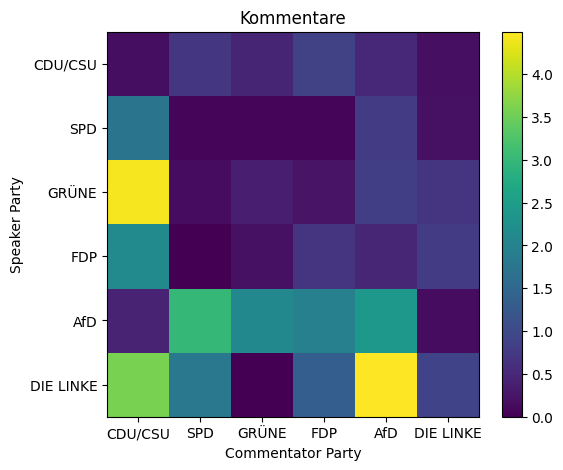

In [196]:
# now normalized + focus only on relevant parties
plt.figure(figsize=(6, 5))
plt.imshow(comment_matrix_normalized_sents_seats[:6,:6], cmap='viridis', aspect='auto')

# labels
plt.xticks(ticks=np.arange(6), labels=parties[:6])
plt.yticks(ticks=np.arange(6), labels=parties[:6])
plt.colorbar()
plt.xlabel('Commentator Party')
plt.ylabel('Speaker Party')
plt.title('Kommentare')

plt.show()

# Do it for the 20. BT-Period up until now

In [180]:
def get_comment_matrix_for_protocol(protocol_filename):
    with open('data/parsed_protocols/'+protocol_filename) as f:
        protocol = json.load(f)
    party_indices = {party: i for i, party in enumerate(parties)}

    aggregated_matrix = np.zeros([len(parties), len(parties)], dtype= int)
    num_sents = np.zeros(len(parties), dtype = int)
    nlp = German()
    nlp.add_pipe('sentencizer')
    
    for speech in protocol:
        party_speaker = speech['speaker']['party']
        speaker_party_index = party_indices[party_speaker]
        for comment in speech['comments']:
            comment_party = comment['commentator']['party']
            if comment_party== 'CDU' or comment_party=='CSU':
                comment_party = 'CDU/CSU'
            aggregated_matrix[speaker_party_index][party_indices[comment_party]] += 1
        
        # get total number of sents
        party_speaker = speech['speaker']['party']
        doc = nlp(speech['text'])
        num_sents[party_indices[party_speaker]] +=  sum(1 for sent in doc.sents)
        
    return aggregated_matrix, num_sents

In [181]:
def get_comment_matrix_timespan(start_date, end_date):
    out_comment_matrix = np.zeros([len(parties), len(parties)], dtype = int)
    out_sent_counts = np.zeros(len(parties), dtype = int)
    relevant_protocols = [protocol_filename for protocol_filename in os.listdir('./data/parsed_protocols/') if protocol_filename[7:-5] >start_date and protocol_filename[7:-5] <end_date]
    for protocol_filename in tqdm(relevant_protocols):
        mat1, sent_counts= get_comment_matrix_for_protocol(protocol_filename)
        out_comment_matrix += mat1
        out_sent_counts += sent_counts
    return out_comment_matrix, out_sent_counts

In [213]:
comment_matrix_20, sent_counts_20 = get_comment_matrix_timespan('2021-10-26', '2024-05-21') # current BT

100%|██████████| 169/169 [01:32<00:00,  1.83it/s]


In [214]:
def normalize_comment_matrix(comment_matrix, norm_vector, seats = False, bt_period = 20):
    
    out_mat = np.array(comment_matrix, dtype = float)
    for i in range(len(parties)):
        out_mat[i,:] /= norm_vector[i]+1 #smoothing for 0 values

    if seats:
        if bt_period == 20:
            second_votes= [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB
        elif bt_period == 19:
            second_votes = [0.329, 0.205, 0.089, 0.107, 0.092, 0.126]
        elif bt_period == 18:
            second_votes = [0.415, 0.257, 0.084, 0.048, 0.086, 0.047 ]
        else:
            KeyError('Invalid BT-Period')
        for party in parties[:6]:
            out_mat[:,party_indices[party]] /= vote_percentages[party_indices[party]]
    return out_mat

In [215]:
comment_matrix_sent_norm_20 = normalize_comment_matrix(comment_matrix_20, sent_counts_20, seats=False)

In [216]:
comment_matrix_sent_seats_norm_20 = normalize_comment_matrix(comment_matrix_20, sent_counts_20, seats=True)

In [217]:
def plot_relevant_parties(comment_matrix):
    # now normalized + focus only on relevant parties
    plt.figure(figsize=(6, 5))
    plt.imshow(comment_matrix[:6,:6], cmap='viridis', aspect='auto')

    # labels
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.xticks(ticks=np.arange(6), labels=parties[:6])
    plt.yticks(ticks=np.arange(6), labels=parties[:6])
    plt.colorbar()
    plt.xlabel('Commentator Party')
    plt.ylabel('Speaker Party')

    plt.show()

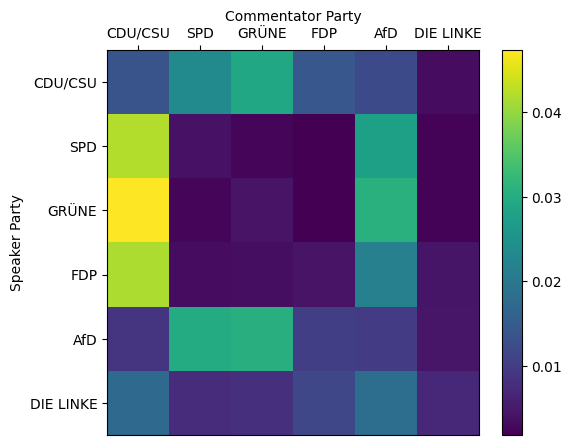

In [218]:
plot_relevant_parties(comment_matrix_sent_norm_20)

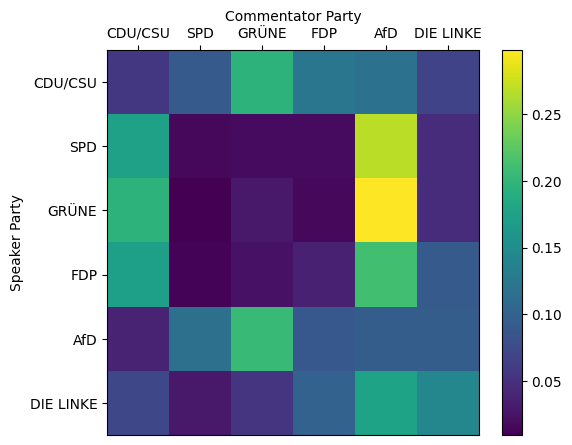

In [219]:
plot_relevant_parties(comment_matrix_sent_seats_norm_20)

In [197]:
comment_matrix_19, sent_counts_19 = get_comment_matrix_timespan('2017-10-26', '2021-10-26') # last BT

100%|██████████| 238/238 [02:42<00:00,  1.46it/s]


In [226]:
comment_matrix_sent_norm_19 = normalize_comment_matrix(comment_matrix_19, sent_counts_19)

In [224]:
comment_matrix_sent_seats_norm_19 = normalize_comment_matrix(comment_matrix_19, sent_counts_19, seats=True, bt_period=19)

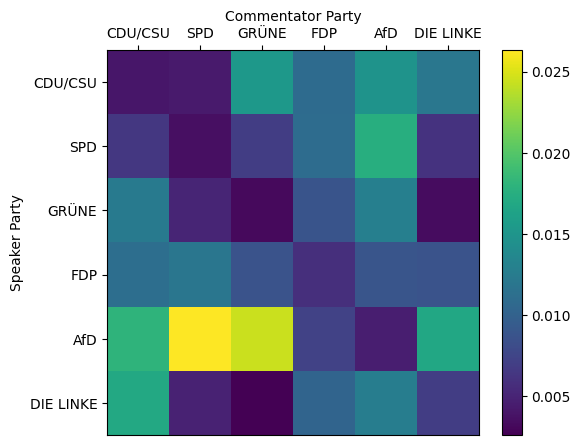

In [227]:
plot_relevant_parties(comment_matrix_sent_norm_19)

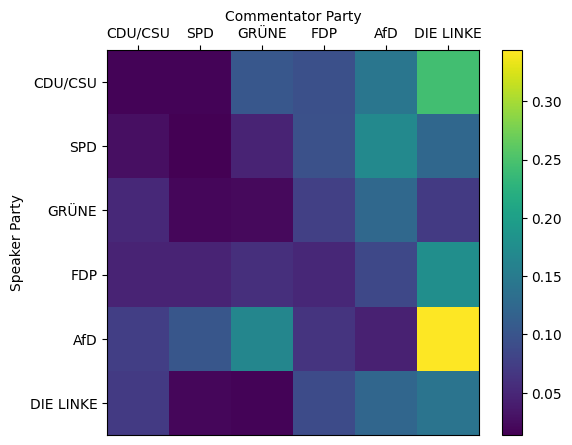

In [225]:
plot_relevant_parties(comment_matrix_sent_seats_norm_19)

In [239]:
comment_matrix_18, sent_counts_18 = get_comment_matrix_timespan('2013-10-22', '2017-09-05') # second to last BT

100%|██████████| 243/243 [01:43<00:00,  2.34it/s]


In [249]:
comment_matrix_sent_norm_18 = normalize_comment_matrix(comment_matrix_18, sent_counts_18)
comment_matrix_sent_norm_18[party_indices['FDP']] = np.zeros(len(parties), dtype = float) # throw irrelevant data away
# expl.: Cornelia Pieper FDP is minister at the start of this BT Period but FDP is not in the BT. -> due to low speech time -> high normalized output
# she also occurs in only one protocol of this period

In [250]:
comment_matrix_sent_seats_norm_18 = normalize_comment_matrix(comment_matrix_18, sent_counts_18, seats=True, bt_period=18)
comment_matrix_sent_seats_norm_18[party_indices['FDP']] = np.zeros(len(parties), dtype = float)

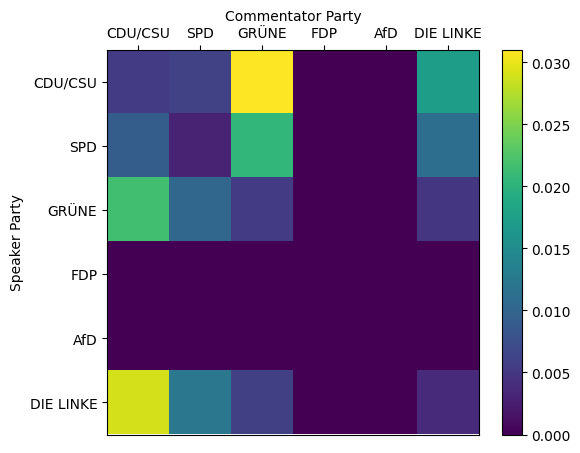

In [251]:
plot_relevant_parties(comment_matrix_sent_norm_18)

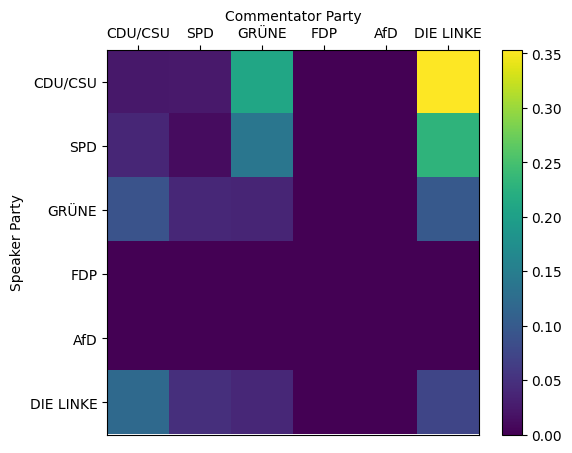

In [252]:
plot_relevant_parties(comment_matrix_sent_seats_norm_18)

In [248]:
start_date, end_date = '2013-10-22', '2017-09-05'
relevant_protocols = [protocol_filename for protocol_filename in os.listdir('./data/parsed_protocols/') if protocol_filename[7:-5] >start_date and protocol_filename[7:-5] <end_date]
for protocol_filename in relevant_protocols:
    with open('data/parsed_protocols/'+protocol_filename) as f:
        protocol = json.load(f)
    party_indices = {party: i for i, party in enumerate(parties)}
    for speech in protocol:
        if speech['speaker']['party'] == "FDP":
            print(f"fdp found in {protocol_filename}, speaker: {speech['speaker']}")
        for comment in speech['comments']:
            if comment['commentator']['party'] == "FDP":
                print(f"fdp found in {protocol_filename}, speaker: {speech['speaker']}")

fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found 